# Many models with gapminder: `.apply()` vs a for-loop

This notebook fits one linear regression of life expectancy on year for every country in the gapminder dataset, then compares two ways of doing the same job: the functional `.apply()` style and a plain for-loop. Along the way it times both approaches and draws a set of small-multiple charts so we can read the results by continent.

Work through the cells in order. Each code cell keeps the original comments so you can see exactly what every line does.

## 1. Importing the libraries

We load pandas for the data table, statsmodels for the regression, the gapminder dataset itself, seaborn and matplotlib for the charts, and the built-in `time` module so we can measure how long each approach takes.

In [7]:
# We begin by importing all the tools (libraries) we will need for this analysis.

# pandas is the primary library for data manipulation and analysis in Python.
# We use it to work with our data in a table-like structure called a DataFrame.
import pandas as pd

# statsmodels is a powerful library for statistical modeling, including regressions.
import statsmodels.api as sm
import statsmodels.formula.api as smf # This sub-library lets us write models using R-style formulas.

# gapminder is a simple library that contains the dataset we will be using.
from gapminder import gapminder

# seaborn and matplotlib are used for data visualization (creating plots and graphs).
# Seaborn is built on top of Matplotlib and provides a more high-level interface.
import seaborn as sns
import matplotlib.pyplot as plt

# time is a built-in Python library that lets us measure how long our code takes to run.
import time

## 2. Setup and preparing the data

We centre year on 1952 so the intercept of each regression reads as the estimated life expectancy in 1952 rather than in year zero. Then we group the single big table into one small group per country and continent, which is what lets us fit a separate model for each country.

In [8]:
# Here, we set up a key variable and prepare our data for analysis.

# The goal is to model life expectancy as a function of years passed since 1952.
# Instead of using the full year (e.g., 1952, 1957), we'll use the difference
# (e.g., 0, 5). This makes the regression's intercept more meaningful.
# The intercept will now represent the estimated life expectancy in the year 1952.
yearMin = 1952

# The core of our analysis is to run one regression for EACH country.
# To do this, we first need to group our single large DataFrame into smaller
# chunks, where each chunk contains the data for only one country.
# The .groupby() method does this for us, creating a special grouped object.
nested_data = gapminder.groupby(['country', 'continent'])

## 3. The regression function

`tidy_lm` takes the data for one country, fits life expectancy against years since 1952, and hands back a tidy table with one row per coefficient (the intercept and the slope) together with its standard error and confidence interval. Writing it once means we can reuse it for all 142 countries.

In [9]:
# We write a reusable function to perform the linear regression. This keeps our
# code clean and avoids repetition.

def tidy_lm(data):
    """
    This function takes a DataFrame for a single country, fits a linear model
    of lifeExp vs. year, and returns the model's key results in a clean DataFrame.
    """
    # smf.ols() stands for "ordinary least squares" from a formula.
    # The formula 'lifeExp ~ I(year - yearMin)' means we are modeling
    # lifeExp as a function of the year passed since yearMin (1952).
    # .fit() runs the regression.
    model = smf.ols(f'lifeExp ~ I(year - {yearMin})', data=data).fit()
    
    # After fitting, we extract the results into a "tidy" format.
    # A tidy format means each row is an observation and each column is a variable.
    
    # Get the model coefficients (the intercept and the slope) and rename the column.
    coeffs = model.params.rename('estimate')
    
    # Get the 95% confidence interval for each coefficient.
    conf_int = model.conf_int().rename(columns={0: 'conf.low', 1: 'conf.high'})
    
    # Get the standard error for each coefficient.
    std_err = model.bse.rename('std.error')
    
    # Combine the coefficients, standard errors, and confidence intervals into one DataFrame.
    # `axis=1` tells pandas to stack them side-by-side as new columns.
    # .reset_index() turns the coefficient names (like 'Intercept') into a proper column.
    results = pd.concat([coeffs, std_err, conf_int], axis=1).reset_index()
    results = results.rename(columns={'index': 'term'}) # Rename the new column to 'term'.
    
    return results

## 4. Running the regressions two ways

Here we apply `tidy_lm` to every country. The first cell uses the functional `.apply()` method, which runs the function on each group and stitches the results together for us. The second cell does the identical work with an explicit for-loop, building a list of results and concatenating them at the end. Both are timed so we can compare them.

In [10]:
# Now we will use our `tidy_lm` function to analyze the data for every country.
# We will show two ways to do this: a functional approach and a traditional loop.

# --- Method 1: Functional Approach with .apply() ---
# This is a very common and "Pythonic" way to work with grouped data in pandas.
# The .apply() method automatically runs our `tidy_lm` function on every group
# (i.e., every country) and then stitches the results back together for us.

print("--- Running Functional .apply() Method ---")
start_time_apply = time.perf_counter() # Start the timer

# `include_groups=False` is a modern setting to prevent a future warning.
many_models = nested_data.apply(tidy_lm, include_groups=False).reset_index()

end_time_apply = time.perf_counter() # Stop the timer
print(f"Time taken for .apply() method: {end_time_apply - start_time_apply:.4f} seconds")
print("First 5 rows of result from .apply():")
print(many_models.head())
print("\n" + "="*50 + "\n")


# --- Method 2: For-Loop Approach (Equivalent Method) ---
# This approach does the exact same thing as .apply(), but in a more explicit
# step-by-step manner. It can be easier to understand if you are new to programming.

print("--- Running For-Loop Method ---")
start_time_loop = time.perf_counter() # Start the timer

# Step 1: Initialize an empty list to store the results from each country's regression.
results_list = []

# Step 2: Iterate directly over our grouped object.
# In each iteration, we get the group's `name` (a tuple like ('Afghanistan', 'Asia'))
# and the actual data for that group (`group_df`).
for name, group_df in nested_data:
    country, continent = name # Unpack the name tuple into separate variables.
    
    # Step 3: Run our regression function on the data for this one country.
    country_coeffs = tidy_lm(group_df)
    
    # Step 4: The result from tidy_lm doesn't know which country it was for,
    # so we add 'country' and 'continent' columns to it.
    country_coeffs['country'] = country
    country_coeffs['continent'] = continent
    
    # Step 5: Add this country's results DataFrame to our list.
    results_list.append(country_coeffs)

# Step 6: After the loop finishes, `results_list` contains 142 small DataFrames.
# `pd.concat()` merges them all into a single, large DataFrame.
many_models_loop = pd.concat(results_list, ignore_index=True)

end_time_loop = time.perf_counter() # Stop the timer
print(f"Time taken for for-loop method: {end_time_loop - start_time_loop:.4f} seconds")
print("First 5 rows of result from for-loop:")
print(many_models_loop.head())

--- Running Functional .apply() Method ---
Time taken for .apply() method: 0.3251 seconds
First 5 rows of result from .apply():
       country continent  level_2            term   estimate  std.error  \
0  Afghanistan      Asia        0       Intercept  29.907295   0.664000   
1  Afghanistan      Asia        1  I(year - 1952)   0.275329   0.020451   
2      Albania    Europe        0       Intercept  59.229128   1.076844   
3      Albania    Europe        1  I(year - 1952)   0.334683   0.033166   
4      Algeria    Africa        0       Intercept  43.374974   0.718420   

    conf.low  conf.high  
0  28.427812  31.386778  
1   0.229761   0.320896  
2  56.829770  61.628486  
3   0.260784   0.408583  
4  41.774234  44.975714  


--- Running For-Loop Method ---
Time taken for for-loop method: 0.2769 seconds
First 5 rows of result from for-loop:
             term   estimate  std.error   conf.low  conf.high      country  \
0       Intercept  29.907295   0.664000  28.427812  31.386778  Afgha

## 5. Preparing the results for plotting

We split the combined results into two pieces: the intercepts (life expectancy in 1952) and the slopes (the yearly rate of improvement). Each piece is sorted from highest to lowest so the charts are easy to scan.

In [11]:
# Now that we have our regression results, we need to separate the intercepts
# (life expectancy in 1952) from the slopes (yearly improvement) to plot them.

# --- Extract the Intercepts ---
# We filter the `many_models` DataFrame to get only the rows where the 'term' is 'Intercept'.
# .copy() is used to avoid a SettingWithCopyWarning from pandas.
intercepts = many_models[many_models['term'] == 'Intercept'].copy()

# For our plots, we want the y-axis (countries) to be ordered.
# `ascending=False` sorts from the highest life expectancy to the lowest.
# Seaborn will respect this order when it creates the plot.
intercepts = intercepts.sort_values('estimate', ascending=False)

# --- Extract the Slopes ---
# We do the same for the slopes, filtering for the term related to the year.
slopes = many_models[many_models['term'] == f'I(year - {yearMin})'].copy()

# We again sort from highest to lowest to make the plots easy to read.
slopes = slopes.sort_values('estimate', ascending=False)

## 6. Charts

The next three cells draw the visualisations, one continent per small panel. First the intercepts, then the slopes, then the slopes again with their 95% confidence intervals shown as point-and-range plots.

### Plot 1: life expectancy in 1952

A bar chart of each country's intercept, faceted by continent. First we build a sorted list of continents so the panels appear alphabetically.

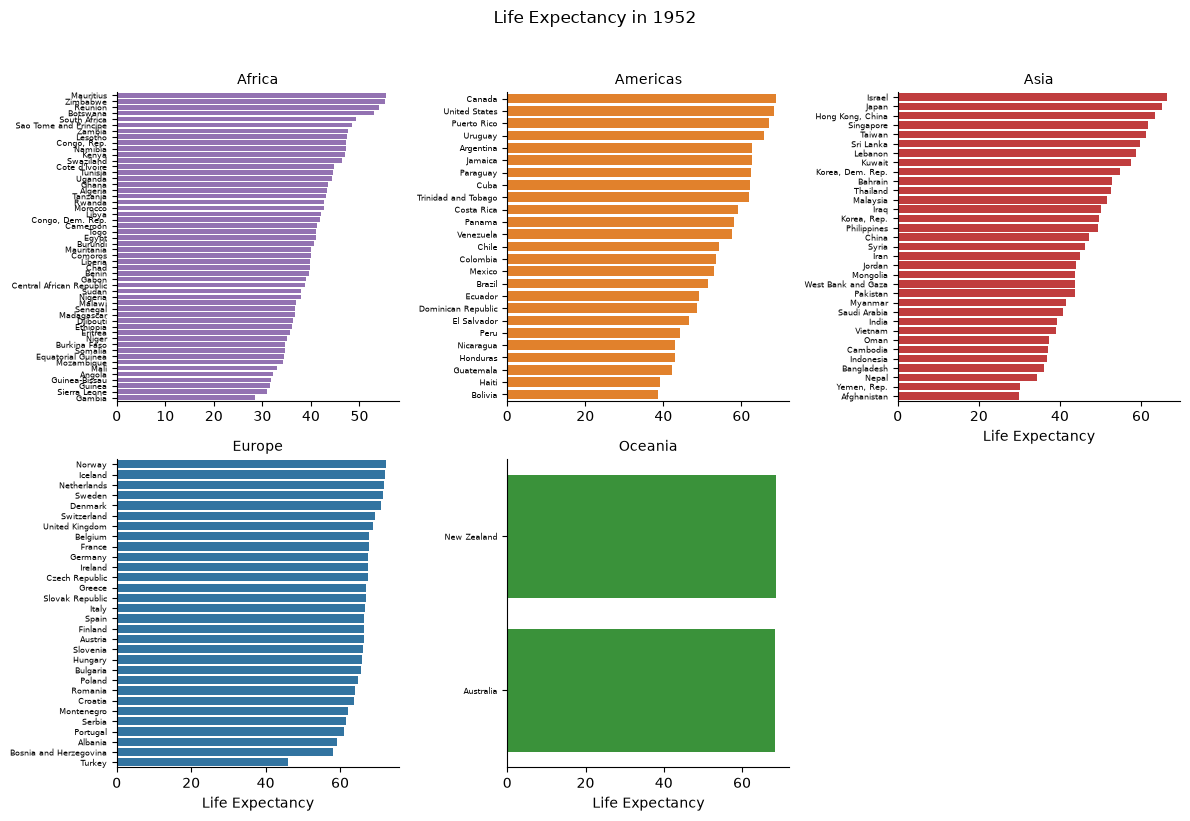

In [12]:
# This section creates the three visualizations requested.

# To ensure the plots of continents appear in alphabetical order (Africa, Americas...),
# we create a sorted list of the unique continent names.
continents_sorted = sorted(gapminder['continent'].unique())

# --- Plot 1: Bar chart of Intercepts (Life expectancy in 1952) ---

# `sns.FacetGrid` is a powerful tool for creating a grid of similar plots.
# We tell it to create a separate plot (`col`) for each 'continent'.
# `col_wrap=3` means it will put 3 plots on each row.
# `sharex=False, sharey=False` means each plot can have its own axis scales.
# `col_order` uses our sorted list to arrange the plots alphabetically.
g_intercepts = sns.FacetGrid(
    intercepts, 
    col="continent", 
    hue="continent", 
    col_wrap=3, 
    sharex=False, 
    sharey=False, 
    height=4,
    col_order=continents_sorted
)
# `.map_dataframe()` applies a plotting function (here, `sns.barplot`) to the
# data in each facet (each small plot).
g_intercepts.map_dataframe(sns.barplot, x="estimate", y="country", dodge=False)

# Add titles and labels for clarity.
g_intercepts.fig.suptitle('Life Expectancy in 1952', y=1.02)
g_intercepts.set_axis_labels("Life Expectancy", "")
g_intercepts.set_titles(col_template="{col_name}")

# This loop reduces the font size of the country names on the y-axis to prevent overlap.
for ax in g_intercepts.axes.flat:
    if ax:
        ax.tick_params(axis='y', labelsize=6)

# `plt.tight_layout()` adjusts plot parameters for a tight layout.
plt.tight_layout()
# `plt.show()` displays the plot.
plt.show()

### Plot 2: average yearly improvement

The same layout, now showing each country's slope: how fast life expectancy rose per year between 1952 and 2007.

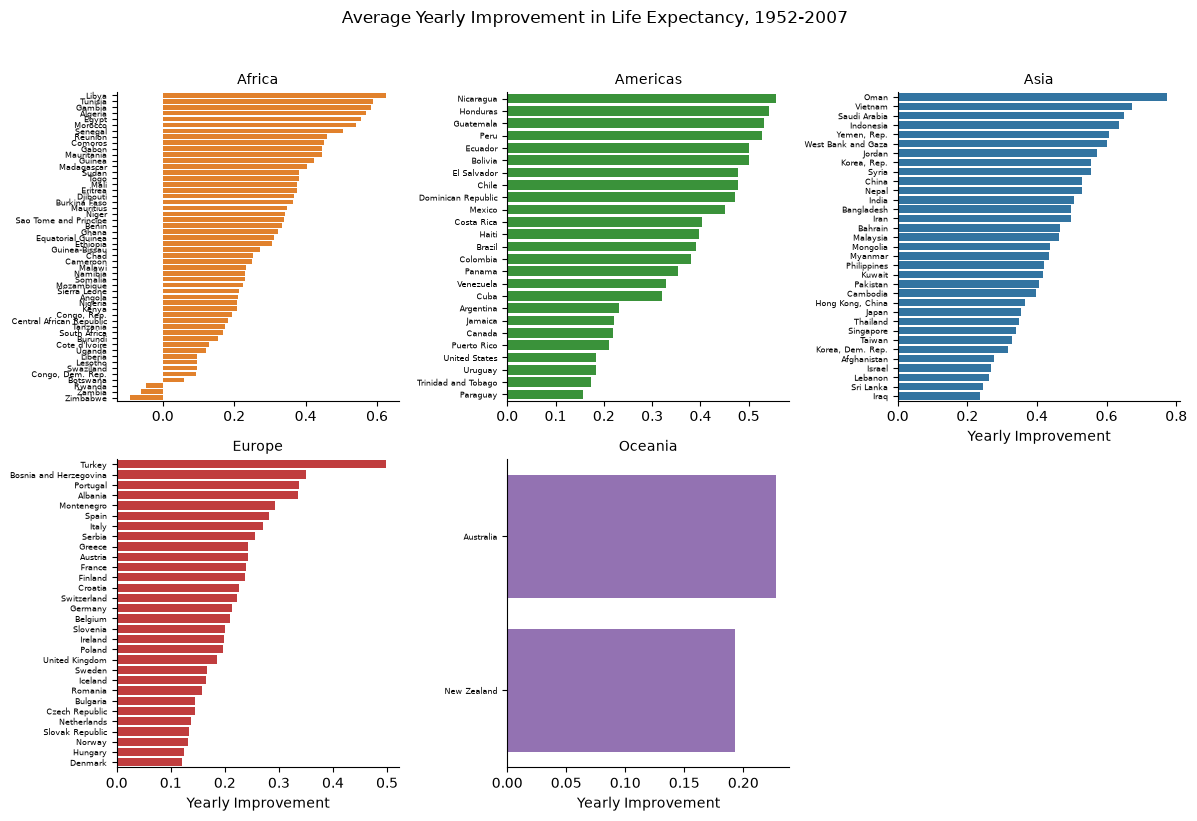

In [13]:
# --- Plot 2: Bar chart of Slopes (Average yearly improvement) ---
# This plot follows the exact same logic as the first one, but uses the `slopes` DataFrame.

g_slopes = sns.FacetGrid(
    slopes, 
    col="continent", 
    hue="continent", 
    col_wrap=3, 
    sharex=False, 
    sharey=False, 
    height=4,
    col_order=continents_sorted
)
g_slopes.map_dataframe(sns.barplot, x="estimate", y="country", dodge=False)
g_slopes.fig.suptitle('Average Yearly Improvement in Life Expectancy, 1952-2007', y=1.02)
g_slopes.set_axis_labels("Yearly Improvement", "")
g_slopes.set_titles(col_template="{col_name}")

for ax in g_slopes.axes.flat:
    if ax:
        ax.tick_params(axis='y', labelsize=6)

plt.tight_layout()
plt.show()

### Plot 3: yearly improvement with confidence intervals

A point-and-range version of the slopes. Since seaborn has no built-in point-range plot that fits here, we define a small helper using matplotlib's `errorbar`, and flip the y-axis so the ordering matches Plot 2.

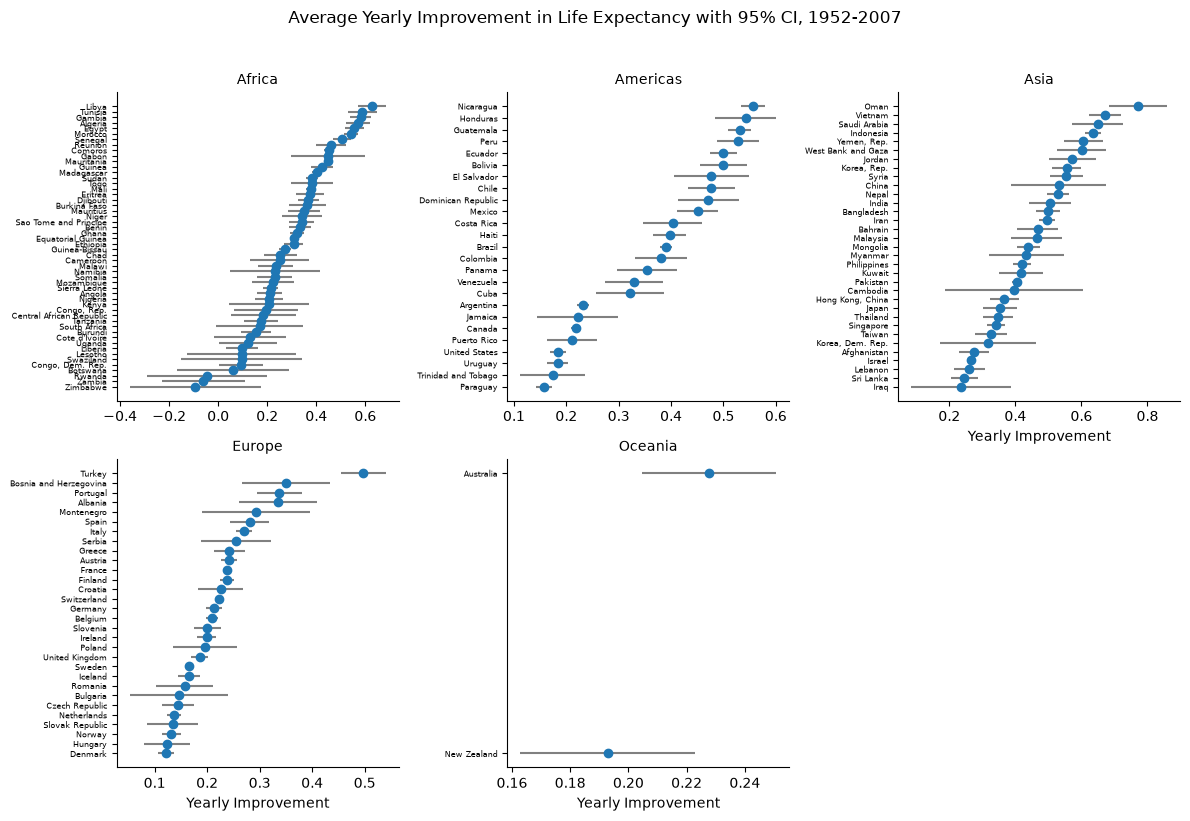

In [14]:
# --- Plot 3: Point-range plot of Slopes with Confidence Intervals ---
# This plot shows the slope estimate as a point and its confidence interval as a line.

g_slopes_ci = sns.FacetGrid(
    slopes, 
    col="continent", 
    col_wrap=3, 
    sharex=False, 
    sharey=False, 
    height=4,
    col_order=continents_sorted
)

# Since Seaborn doesn't have a built-in "point-range" plot that works well with
# `map_dataframe` in this way, we define our own simple plotting function.
def point_range_plot(data, **kwargs):
    # We use Matplotlib's `errorbar` function to draw the point and its error bars.
    plt.errorbar(y=data['country'], x=data['estimate'], 
                 xerr=[data['estimate'] - data['conf.low'], data['conf.high'] - data['estimate']],
                 fmt='o', ecolor='gray', capthick=1)

# We map our custom function to the FacetGrid.
g_slopes_ci.map_dataframe(point_range_plot)
g_slopes_ci.fig.suptitle('Average Yearly Improvement in Life Expectancy with 95% CI, 1952-2007', y=1.02)
g_slopes_ci.set_axis_labels("Yearly Improvement", "")
g_slopes_ci.set_titles(col_template="{col_name}")

# Final adjustments for this specific plot.
for ax in g_slopes_ci.axes.flat:
    if ax:
        ax.tick_params(axis='y', labelsize=6)
        # Matplotlib's `errorbar` plots from bottom-to-top by default.
        # This is the opposite of `barplot`. `ax.invert_yaxis()` flips the y-axis
        # to ensure the country with the highest slope is at the top, matching Plot 2.
        ax.invert_yaxis()

plt.tight_layout()
plt.show()

## Key differences and observations

Key Differences and Observations
Code Structure: The .apply() method is more concise. It abstracts the iteration away, allowing you to focus on the function that needs to be applied to each group. 
The for loop is more verbose but explicitly shows every step: initializing a list, iterating, processing, adding identifying information, and appending.

Performance: When you run the code, you will likely see that the performance is very similar. This is because the bottleneck is not the iteration itself 
(Python loops vs. pandas' internal loops), but the time it takes to run the statsmodels regression (tidy_lm) for each of the 142 countries. The overhead 
of the loop is negligible compared to the computational work being done in each iteration. For simpler operations (like calculating a mean or sum), 
pandas' internal methods are often significantly faster than a Python for loop.

Readability: Which one is "better" is often a matter of preference and team convention. The functional apply approach is considered more idiomatic within the pandas ecosystem. The for loop might be more intuitive for those coming from other programming backgrounds or for complex workflows where you need to manage state between iterations.